In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/student-mat.csv", sep=';')

In [3]:
def categorize_grade(g):
    if g < 10:
        return "Weak"
    elif g < 15:
        return "Average"
    else:
        return "Excellent"

df["performance"] = df["G3"].apply(categorize_grade)

In [4]:
df = df.drop("G3", axis=1)

In [5]:
X = df.drop("performance", axis=1)

y = df["performance"]

In [6]:
label_encoder = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object' or X[column].dtype == 'str':
        X[column] = label_encoder.fit_transform(X[column])

In [7]:
y = label_encoder.fit_transform(y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# TRAIN LOGISTIC REGRESSION

In [10]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.8607594936708861


# TRAIN DECISION TREE

In [11]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.8481012658227848


# TRAIN RANDOM FOREST

In [13]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8607594936708861


# TRAIN KNN

In [14]:
knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.569620253164557


# COMPARE MODELS

In [15]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        log_acc,
        tree_acc,
        rf_acc,
        knn_acc
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.860759
1,Decision Tree,0.848101
2,Random Forest,0.860759
3,KNN,0.569620


# VISUALIZE MODEL ACCURACY

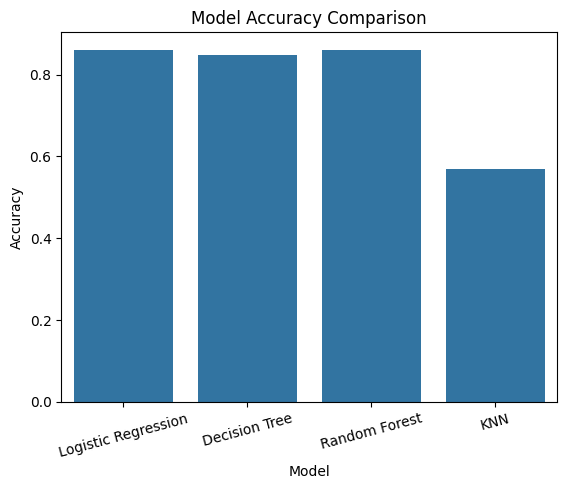

In [16]:
sns.barplot(x="Model", y="Accuracy", data=model_results)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# Although Logistic Regression and Random Forest achieved similar accuracy scores, Random Forest was selected as the final model due to its ensemble learning capability, robustness, and ability to provide feature importance analysis.

In [17]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       1.00      0.80      0.89        20
           2       0.86      0.89      0.87        27

    accuracy                           0.86        79
   macro avg       0.89      0.85      0.87        79
weighted avg       0.87      0.86      0.86        79



# The Random Forest classifier achieved an overall accuracy of 86%, with strong and balanced precision, recall, and F1-scores across all performance categories, indicating reliable classification performance.

# Class 1 achieved perfect precision, indicating that all predictions for this category were correct, although some actual instances were missed due to slightly lower recall.

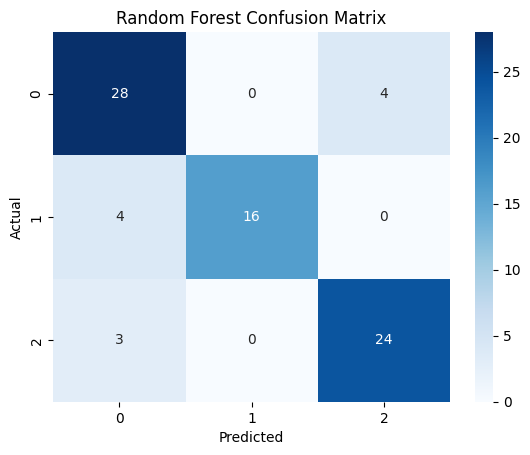

In [18]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# The confusion matrix demonstrates strong classification performance, with most predictions concentrated along the diagonal, indicating that the Random Forest model correctly classified the majority of student performance categories.

# Misclassifications were relatively limited and primarily occurred between neighboring performance categories, suggesting that the model learned meaningful decision boundaries.